# This is an example notebook for ring spreading test

After building ``RAPID``, the executable binary ``simulation`` is located in the bin folder.


In [1]:
import subprocess
import os

# ensure we run from project root if notebook is inside "notebooks"
cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    os.chdir("..")

yaml_files = [
    "notebooks/configs/convergence_test_128.yaml",
    "notebooks/configs/convergence_test_256.yaml",
    "notebooks/configs/convergence_test_512.yaml",
    "notebooks/configs/convergence_test_1024.yaml",
    "notebooks/configs/convergence_test_2048.yaml",
    "notebooks/configs/convergence_test_4096.yaml"
]

for yaml_path in yaml_files:
    print("\n==============================================")
    print(f"Running simulation for: {yaml_path}")
    print("==============================================\n")

    cmd = [
        "python3",
        "run_simulation.py",
        "--config",
        yaml_path
    ]

    process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

    for line in process.stdout:
        print(line.rstrip("\n"))

    process.wait()

    print(f"\nSimulation finished for: {yaml_path}\n")



Running simulation for: notebooks/configs/convergence_test_128.yaml

[PY-WRAPPER] Terminal panels disabled (YAML setting).

[PY-WRAPPER] --- Running: Main Simulation Program ---
[PY-WRAPPER] The current command-line arguments are:
 ./bin/simulation -v -no_panels -evol 1.0 -test ring_viscosity -n 128 -ri 1.0 -ro 50.0 -disk_mass 0.01 -alpha_init 0.01 -stellar_mass 1.0 -inner_bc parabolic -outer_bc reflecting -o notebooks/convergence_test/convergence_128 -tmax 1 -outfreq 1
[PY-WRAPPER] Setting OMP_NUM_THREADS=1 for this run.
[PY-WRAPPER] Start running the binary (./bin/simulation) at 2026-09-15 19:47:10...

||                                                                      ||
||                        RAPID SIMULATION CORE                         ||
||                            Version: 2.2.4                            ||
||                                                                      ||
||                  Lead Developer: [D. Tarczay-Nehez]                  ||
||          

## Calculate numerical convergence

Already inside notebooks.


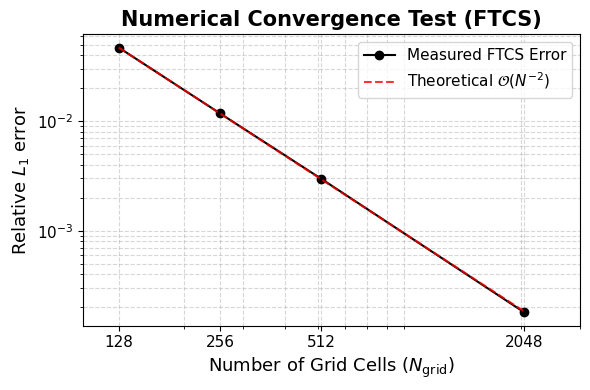

Saved: ring_numerical_convergence.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt

import os

# current working directory
cwd = os.getcwd()

# if we are NOT inside notebooks, try to find it
if os.path.basename(cwd) != "notebooks":
    # search for a notebooks directory in the current tree
    for root, dirs, files in os.walk(".", topdown=True):
        if "notebooks" in dirs:
            notebooks_path = os.path.join(root, "notebooks")
            os.chdir(notebooks_path)
            print(f"Changed directory to: {notebooks_path}")
            break
    else:
        print("No 'notebooks' directory found. Staying in current directory.")
else:
    print("Already inside notebooks.")


# 1. Resolutions to be tested (reference: N=4096)
Ns = [128, 256, 512, 2048]
errors = []

# 2. Load the finest resolution as the reference (N=4096)
ref_path = "convergence_test/convergence_4096/LOGS/ring_profile_t_000000.dat"
try:
    ref = np.loadtxt(ref_path)
    r_ref = ref[:, 0]
    sigma_ref = ref[:, 1]
except OSError:
    raise FileNotFoundError(f"Reference file not found: {ref_path}")

# 3. Error calculation loop for each grid resolution
for N in Ns:
    path = f"convergence_test/convergence_{N:d}/LOGS/ring_profile_t_000000.dat"
    try:
        data = np.loadtxt(path)
        r = data[:, 0]
        sigma = data[:, 1]
    except OSError:
        print(f"Warning: '{path}' not found, skipping...")
        continue

    # Interpolate coarse grid onto fine reference grid
    sigma_interp = np.interp(r_ref, r, sigma)

    # Relative L1 error
    num = np.trapezoid(np.abs(sigma_interp - sigma_ref), r_ref)
    den = np.trapezoid(np.abs(sigma_ref), r_ref)

    errors.append(num / den)

# Adjust Ns list if some files were missing
Ns = Ns[:len(errors)]

# 4. Plotting
if errors:
    fig = plt.figure(figsize=(6, 4))

    # Measured FTCS errors
    plt.loglog(Ns, errors, marker="o", ls="-", color="black", lw=1.5,
               label="Measured FTCS Error")

    # Theoretical second-order convergence line
    ideal_error = [errors[0] * (Ns[0] / N)**2 for N in Ns]
    plt.loglog(Ns, ideal_error, ls="--", color="red", alpha=0.8,
               label=r"Theoretical $\mathcal{O}(N^{-2})$")

    # Labels
    plt.xlabel(r"Number of Grid Cells ($N_{\rm grid}$)", fontsize=13)
    plt.ylabel(r"Relative $L_1$ error", fontsize=13)

    plt.xticks(Ns, labels=[str(n) for n in Ns], fontsize=11)
    plt.yticks(fontsize=11)

    plt.title("Numerical Convergence Test (FTCS)", fontsize=15, fontweight="bold")
    plt.xlim(100, 3000)

    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=11, loc="upper right")

    plt.tight_layout()
    plt.savefig("ring_numerical_convergence.png", dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved: ring_numerical_convergence.png")
else:
    print("No errors calculated — missing data files.")
